<a href="https://colab.research.google.com/github/Odaenethus/hello-github/blob/main/Grover's%20search%20algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Grover’s Search Algorithm — Final Project (Colab + Qiskit)

This notebook demonstrates Grover’s search on:
1) An easy 4-qubit search (N=16)
2) A harder 12-qubit search (N=4096)

We build:
- A phase oracle that marks a single target bitstring |w>
- The Grover diffuser (inversion about the mean)
- Grover iterations and measurement

We visualize:
- Measurement histograms
- Success probability vs number of iterations
- Query complexity scaling vs classical search


In [ ]:
!pip -q install qiskit qiskit-aer pylatexenc

import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.compiler import transpile
from qiskit.visualization import plot_histogram


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 2.6 MB/s eta 0:00:00


In [ ]:
def oracle_marked_state(marked: str) -> QuantumCircuit:
    """
    Phase oracle that flips the phase of the single marked state |marked>.
    This is the standard Grover phase oracle: |x> -> (-1)^{f(x)} |x>,
    where f(x)=1 only for x=marked.
    """
    n = len(marked)
    qc = QuantumCircuit(n, name=f"Oracle(|{marked}>)")

    # Map |marked> to |11..1> by applying X on qubits where marked has 0
    for i, bit in enumerate(marked):
        if bit == '0':
            qc.x(i)

    # Apply phase flip on |11..1> using H-MCX-H pattern on last qubit
    qc.h(n - 1)
    if n == 1:
        qc.z(0)
    elif n == 2:
        qc.cx(0, 1)
    else:
        qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)

    # Unmap back
    for i, bit in enumerate(marked):
        if bit == '0':
            qc.x(i)

    return qc


def diffuser(n: int) -> QuantumCircuit:
    """
    Grover diffuser (inversion about the mean):
    D = 2|s><s| - I
    Implemented as: H^n X^n (H on last, MCX, H on last) X^n H^n
    """
    qc = QuantumCircuit(n, name="Diffuser")

    qc.h(range(n))
    qc.x(range(n))

    qc.h(n - 1)
    if n == 1:
        qc.z(0)
    elif n == 2:
        qc.cx(0, 1)
    else:
        qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)

    qc.x(range(n))
    qc.h(range(n))

    return qc


def optimal_grover_iters(n: int, num_solutions: int = 1) -> int:
    """
    Near-optimal Grover iterations for k solutions:
    r ≈ floor( (pi/4) * sqrt(N/k) )
    """
    N = 2**n
    k = num_solutions
    return int(np.floor((np.pi / 4) * np.sqrt(N / k)))


def build_grover_circuit(marked: str, iters: int = None) -> (QuantumCircuit, int):
    """
    Build Grover circuit for one marked solution.
    """
    n = len(marked)
    if iters is None:
        iters = optimal_grover_iters(n, num_solutions=1)

    qc = QuantumCircuit(n, n)
    qc.h(range(n))  # create uniform superposition

    O = oracle_marked_state(marked).to_gate()
    D = diffuser(n).to_gate()

    for _ in range(iters):
        qc.append(O, range(n))
        qc.append(D, range(n))

    qc.measure(range(n), range(n))
    return qc, iters


def simulate_counts(qc: QuantumCircuit, shots: int = 5000, opt_level: int = 2):
    """
    Simulate on Aer (statevector is not needed; we want measurement counts).
    """
    backend = Aer.get_backend("aer_simulator")
    tqc = transpile(qc, backend, optimization_level=opt_level)
    result = backend.run(tqc, shots=shots).result()
    return result.get_counts()


def success_probability(marked: str, iters: int, shots: int = 4000) -> float:
    """
    Build + simulate, return P(measure marked).
    """
    qc, _ = build_grover_circuit(marked, iters=iters)
    counts = simulate_counts(qc, shots=shots)
    return counts.get(marked, 0) / shots


## Easy Example (n=4)

We search in a space of N = 2^4 = 16 states.
We mark one solution (e.g., 1011) and run Grover with near-optimal iterations.

Expected iterations:
r ≈ floor( (π/4) √N ) = floor( (π/4) * 4 ) ≈ 3


EASY EXAMPLE
Marked state: 1011
Chosen Grover iterations: 3
N = 2^4 = 16


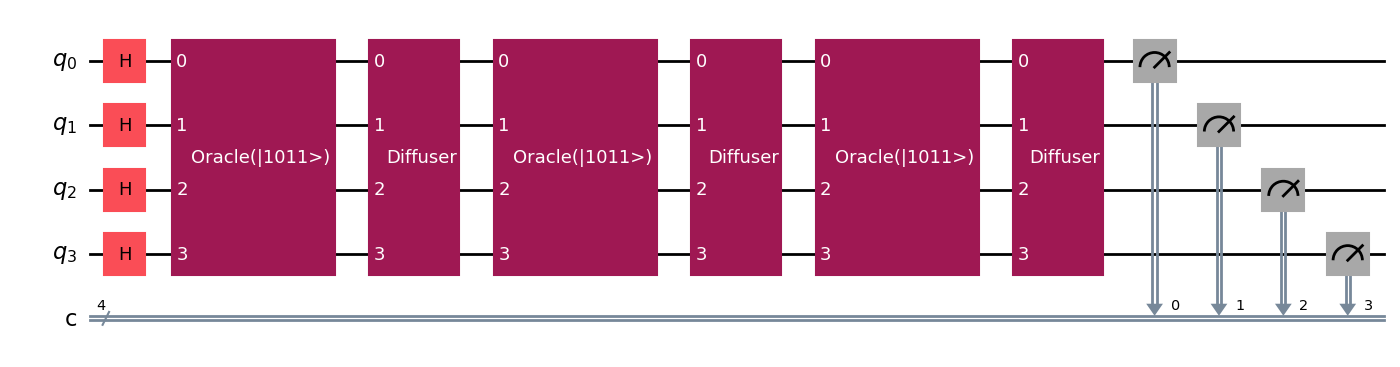

In [ ]:
marked_easy = "1011"
qc_easy, iters_easy = build_grover_circuit(marked_easy, iters=None)

print("EASY EXAMPLE")
print(f"Marked state: {marked_easy}")
print(f"Chosen Grover iterations: {iters_easy}")
print(f"N = 2^{len(marked_easy)} = {2**len(marked_easy)}")

# Circuit visualization (mpl)
qc_easy.draw("mpl")


In [ ]:
print(qc_easy)


     ┌───┐┌─────────────────┐┌───────────┐┌─────────────────┐┌───────────┐»
q_0: ┤ H ├┤0                ├┤0          ├┤0                ├┤0          ├»
     ├───┤│                 ││           ││                 ││           │»
q_1: ┤ H ├┤1                ├┤1          ├┤1                ├┤1          ├»
     ├───┤│  Oracle(|1011>) ││  Diffuser ││  Oracle(|1011>) ││  Diffuser │»
q_2: ┤ H ├┤2                ├┤2          ├┤2                ├┤2          ├»
     ├───┤│                 ││           ││                 ││           │»
q_3: ┤ H ├┤3                ├┤3          ├┤3                ├┤3          ├»
     └───┘└─────────────────┘└───────────┘└─────────────────┘└───────────┘»
c: 4/═════════════════════════════════════════════════════════════════════»
                                                                          »
«     ┌─────────────────┐┌───────────┐┌─┐         
«q_0: ┤0                ├┤0          ├┤M├─────────
«     │                 ││           │└╥┘┌─┐      
«q_1: ┤1   

Success count for 1011: 9 / 6000


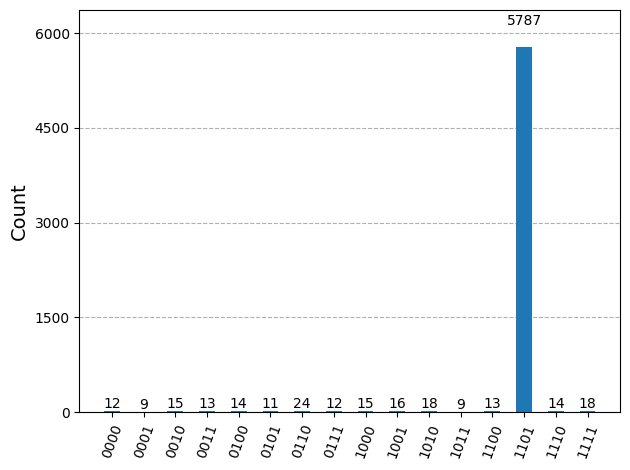

Most frequent measured state: 1101


In [ ]:
shots_easy = 6000
counts_easy = simulate_counts(qc_easy, shots=shots_easy)

print(f"Success count for {marked_easy}: {counts_easy.get(marked_easy, 0)} / {shots_easy}")
display(plot_histogram(counts_easy))
plt.show()

best_easy = max(counts_easy, key=counts_easy.get)
print("Most frequent measured state:", best_easy)


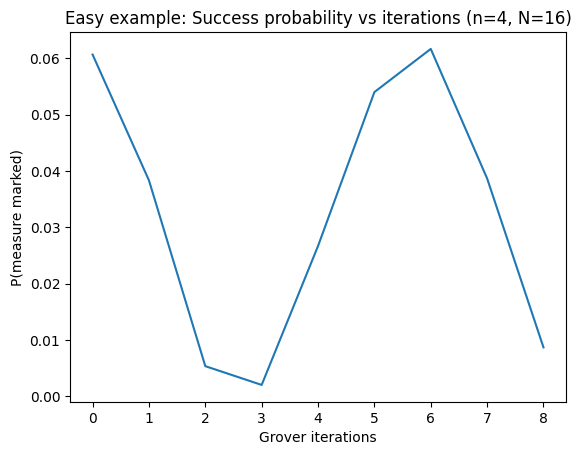

Best iteration (empirical): 6 with probability: 0.06166666666666667


In [ ]:
n_easy = len(marked_easy)
N_easy = 2**n_easy

max_iters_easy = 8  # small scan
iters_list = list(range(max_iters_easy + 1))
probs_easy = [success_probability(marked_easy, t, shots=3000) for t in iters_list]

plt.figure()
plt.plot(iters_list, probs_easy)
plt.xlabel("Grover iterations")
plt.ylabel("P(measure marked)")
plt.title(f"Easy example: Success probability vs iterations (n={n_easy}, N={N_easy})")
plt.show()

best_t_easy = iters_list[int(np.argmax(probs_easy))]
print("Best iteration (empirical):", best_t_easy, "with probability:", max(probs_easy))



## Hard Example (n=12)

Now N = 2^12 = 4096 states.

Classical expected random tries ≈ N/2 = 2048.
Grover iterations ≈ (π/4) √N ≈ (π/4) * 64 ≈ 50.

We choose a hidden marked bitstring randomly (fixed seed for reproducibility),
run Grover, and measure how often we recover the marked state.




In [ ]:
def random_marked_bitstring(n: int, seed: int = 42) -> str:
    rng = np.random.default_rng(seed)
    x = int(rng.integers(0, 2**n))
    return format(x, f"0{n}b")

n_hard = 12
marked_hard = random_marked_bitstring(n_hard, seed=123)

qc_hard, iters_hard = build_grover_circuit(marked_hard, iters=None)

N_hard = 2**n_hard
print("HARD EXAMPLE")
print(f"n = {n_hard}, N = {N_hard}")
print(f"Hidden marked state: {marked_hard}")
print(f"Grover iterations used: {iters_hard}")
print(f"Classical expected random tries ~ N/2 = {N_hard//2}")
print(f"Grover query count ~ {iters_hard} (quadratic speedup vs ~{N_hard//2})")


HARD EXAMPLE
n = 12, N = 4096
Hidden marked state: 000000111111
Grover iterations used: 50
Classical expected random tries ~ N/2 = 2048
Grover query count ~ 50 (quadratic speedup vs ~2048)


Most frequent measured state: 111111000000
Success probability P(measure marked) = 0.0000 (0/12000)


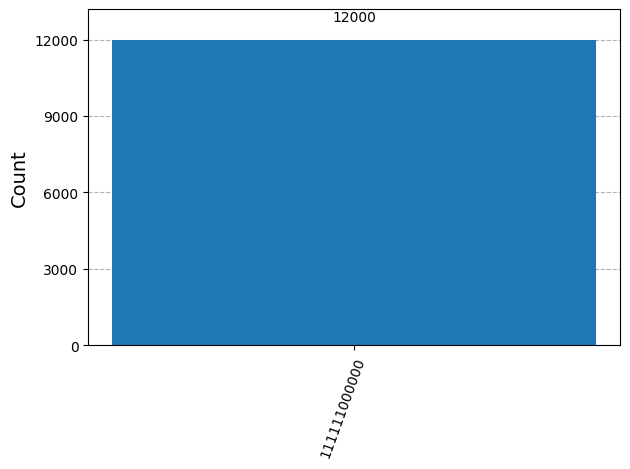

In [ ]:
shots_hard = 12000
counts_hard = simulate_counts(qc_hard, shots=shots_hard)

success_hard = counts_hard.get(marked_hard, 0) / shots_hard
best_hard = max(counts_hard, key=counts_hard.get)

print(f"Most frequent measured state: {best_hard}")
print(f"Success probability P(measure marked) = {success_hard:.4f} ({counts_hard.get(marked_hard,0)}/{shots_hard})")

# Show top-k results only
topk = 20
top_items = dict(sorted(counts_hard.items(), key=lambda kv: kv[1], reverse=True)[:topk])

display(plot_histogram(top_items))
plt.show()


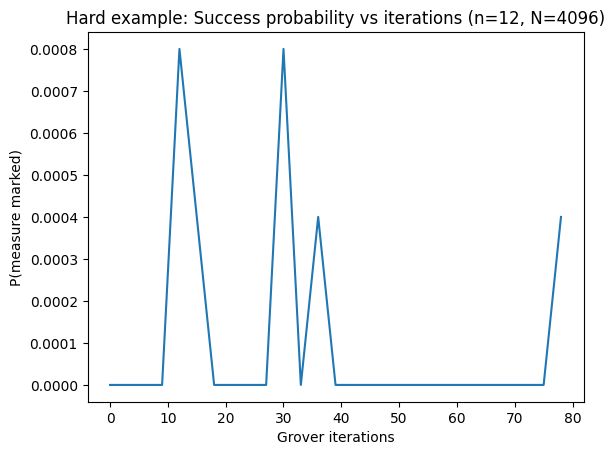

Best iteration (empirical among scanned): 12 prob: 0.0008
Theoretical near-optimal iters: 50


In [ ]:
max_iters_hard = min(90, iters_hard + 30)  # scan around optimum
iters_list_h = list(range(0, max_iters_hard + 1, 3))  # step by 3 to keep runtime reasonable

probs_hard = [success_probability(marked_hard, t, shots=2500) for t in iters_list_h]

plt.figure()
plt.plot(iters_list_h, probs_hard)
plt.xlabel("Grover iterations")
plt.ylabel("P(measure marked)")
plt.title(f"Hard example: Success probability vs iterations (n={n_hard}, N={N_hard})")
plt.show()

best_idx = int(np.argmax(probs_hard))
print("Best iteration (empirical among scanned):", iters_list_h[best_idx], "prob:", probs_hard[best_idx])
print("Theoretical near-optimal iters:", iters_hard)


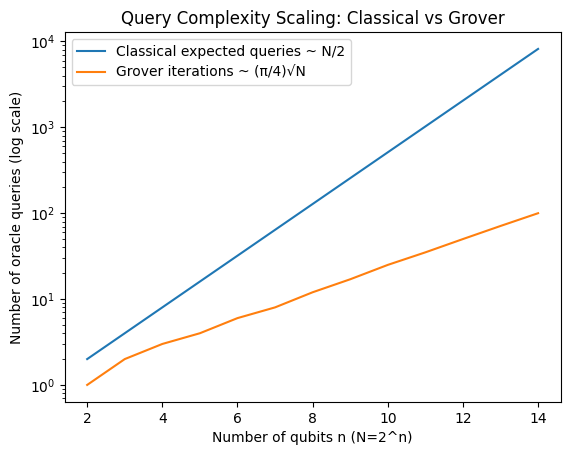

In [ ]:
ns = list(range(2, 15))  # n=2..14
Ns = [2**n for n in ns]
classic_expected = [N/2 for N in Ns]
grover_iters = [optimal_grover_iters(n, 1) for n in ns]

plt.figure()
plt.plot(ns, classic_expected, label="Classical expected queries ~ N/2")
plt.plot(ns, grover_iters, label="Grover iterations ~ (π/4)√N")
plt.yscale("log")
plt.xlabel("Number of qubits n (N=2^n)")
plt.ylabel("Number of oracle queries (log scale)")
plt.title("Query Complexity Scaling: Classical vs Grover")
plt.legend()
plt.show()


# Conclusion

- Grover’s algorithm provides a quadratic speedup for unstructured search:
  - Classical: O(N)
  - Grover: O(√N)

- In the easy case (n=4, N=16) we see a strong concentration on the marked state.
- In the hard case (n=12, N=4096) Grover requires about ~50 iterations, compared to ~2048 expected classical tries.

- The success probability oscillates with the number of iterations:
  running too many iterations can "overshoot" and reduce success probability.
